# Aethel LSTM Sequence Model for Micro Gas Turbine Power Forecasting

This notebook upgrades the tabular baseline into a sequence model that can learn the temporal lag between `input_voltage` changes and `el_power` response.

The workflow is intentionally deployment-oriented:

- Experiments are split exactly as specified: train on `ex_1`, `ex_9`, `ex_20`, `ex_21`, `ex_23`, `ex_24`; validate/evaluate on `ex_4`, `ex_22`.
- Scaling is fit only on the training experiments and saved for FastAPI inference.
- Sliding windows are generated per experiment, so no sequence can cross an experiment boundary.
- Transition and stationary regimes are labeled in the held-out experiments for physics-aware evaluation.
- Monte Carlo Dropout produces a 95% uncertainty band for the frontend UI.

> Note: Because `ex_4` and `ex_22` are used for early stopping and final reporting, the reported metrics are best interpreted as held-out validation metrics rather than a fully untouched test benchmark. For a final scientific claim, reserve a third split if more experiments become available.


In [17]:
from __future__ import annotations

import copy
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Using device: cpu
PyTorch version: 2.12.0+cpu


## 1. Configuration

The default feature set is intentionally `input_voltage` only. That keeps the model deployable when the live API receives a recent voltage history and needs to predict electrical power. If your production telemetry also has a reliable recent measured `el_power` signal, you can add autoregressive features later, but keep the API contract and scaler files in sync.

`LOOKBACK_SECONDS` is converted to a fixed number of samples from the median sampling interval. The dataset is approximately 1 Hz, so a 30 second lag window becomes about 30 time steps.


In [18]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "micro gas turbine electrical energy prediction dataset"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "lstm"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "aethel_lstm_el_power.pth"
FEATURE_SCALER_PATH = ARTIFACT_DIR / "feature_scaler.joblib"
TARGET_SCALER_PATH = ARTIFACT_DIR / "target_scaler.joblib"
CONFIG_PATH = ARTIFACT_DIR / "deployment_config.json"
HISTORY_PATH = ARTIFACT_DIR / "training_history.csv"
PREDICTIONS_PATH = ARTIFACT_DIR / "validation_predictions.csv"

TRAIN_EXPERIMENTS = ["ex_1", "ex_9", "ex_20", "ex_21", "ex_23", "ex_24"]
VALIDATION_EXPERIMENTS = ["ex_4", "ex_22"]

TIME_COLUMN = "time"
FEATURE_COLUMNS = ["input_voltage"]
TARGET_COLUMN = "el_power"
REQUIRED_COLUMNS = [TIME_COLUMN, *FEATURE_COLUMNS, TARGET_COLUMN]

SCALER_KIND = "standard"  # "standard" or "minmax"
LOOKBACK_SECONDS = 30.0
TRANSITION_SECONDS = 30.0
VOLTAGE_STEP_THRESHOLD = 0.05

BATCH_SIZE = 256
MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 18
EARLY_STOPPING_MIN_DELTA = 1e-5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

HIDDEN_SIZE = 96
NUM_LSTM_LAYERS = 2
DROPOUT_RATE = 0.20
MC_DROPOUT_SAMPLES = 50

assert DATA_DIR.exists(), f"Dataset directory not found: {DATA_DIR}"
assert TRAIN_DIR.exists(), f"Train directory not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test directory not found: {TEST_DIR}"


## 2. Load and Validate Experiments

Each experiment is loaded independently, sorted by time, and tagged with `experiment_id`. Keeping this dictionary-of-dataframes structure is important: sequence generation later iterates per experiment and cannot accidentally create a window that spans two experimental runs.


In [19]:
def load_experiment(csv_path: Path, experiment_id: str) -> pd.DataFrame:
    """Load one experiment CSV and validate the expected schema."""
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing experiment file: {csv_path}")

    frame = pd.read_csv(csv_path)
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    if missing_columns:
        raise ValueError(f"{csv_path.name} is missing columns: {missing_columns}")

    frame = frame.loc[:, REQUIRED_COLUMNS].copy()
    for column in REQUIRED_COLUMNS:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    before_drop = len(frame)
    frame = frame.dropna(subset=REQUIRED_COLUMNS).sort_values(TIME_COLUMN).reset_index(drop=True)
    dropped_rows = before_drop - len(frame)
    if dropped_rows:
        print(f"Dropped {dropped_rows} invalid rows from {csv_path.name}")

    frame["experiment_id"] = experiment_id
    frame["row_in_experiment"] = np.arange(len(frame), dtype=np.int64)
    return frame


def load_experiment_group(experiment_ids: Iterable[str], folder: Path) -> Dict[str, pd.DataFrame]:
    """Load a group of experiments from one folder."""
    return {
        experiment_id: load_experiment(folder / f"{experiment_id}.csv", experiment_id)
        for experiment_id in experiment_ids
    }


train_frames = load_experiment_group(TRAIN_EXPERIMENTS, TRAIN_DIR)
validation_frames = load_experiment_group(VALIDATION_EXPERIMENTS, TEST_DIR)

train_raw = pd.concat(train_frames.values(), ignore_index=True)
validation_raw = pd.concat(validation_frames.values(), ignore_index=True)

summary_rows = []
for split_name, frames in (("train", train_frames), ("validation", validation_frames)):
    for experiment_id, frame in frames.items():
        summary_rows.append(
            {
                "split": split_name,
                "experiment_id": experiment_id,
                "rows": len(frame),
                "time_min": frame[TIME_COLUMN].min(),
                "time_max": frame[TIME_COLUMN].max(),
                "voltage_min": frame["input_voltage"].min(),
                "voltage_max": frame["input_voltage"].max(),
                "power_min": frame[TARGET_COLUMN].min(),
                "power_max": frame[TARGET_COLUMN].max(),
            }
        )

summary = pd.DataFrame(summary_rows)
try:
    display(summary)
except NameError:
    print(summary)


,split,experiment_id,rows,time_min,time_max,voltage_min,voltage_max,power_min,power_max
0,train,ex_1,9920,810.070280,10720.658580,3.000,10.000000,932.837260,3249.891217
1,train,ex_9,11819,818.840000,12636.840000,3.445,7.240000,1204.205671,2511.698262
2,train,ex_20,6495,849.220000,7824.000000,3.000,10.000000,1097.030791,3182.431061
3,train,ex_21,6495,847.720000,7776.600000,3.000,10.000000,1045.541020,3191.966802
4,train,ex_23,9188,810.000000,10954.520000,3.000,9.631579,1053.218306,3193.846351
5,train,ex_24,9023,811.040000,10579.600000,3.000,10.000000,1054.175250,3191.101416
6,validation,ex_4,9795,758.425813,10545.532399,3.000,10.000000,1109.522853,3393.228566
7,validation,ex_22,8490,880.300000,10427.580000,3.000,10.000000,1022.500305,3184.621625


## 3. Estimate Sampling Interval and Sequence Length

The lookback is specified in seconds but the LSTM consumes a fixed number of time steps. We estimate the median sampling interval from the training split only, then derive both the LSTM window length and transition labeling window.


In [20]:
def estimate_median_dt(frames: Dict[str, pd.DataFrame]) -> float:
    """Estimate the global median sampling interval across experiments."""
    dt_values = []
    for frame in frames.values():
        dt = frame[TIME_COLUMN].diff().dropna()
        dt = dt[dt > 0]
        if len(dt):
            dt_values.extend(dt.to_numpy(dtype=np.float64))

    if not dt_values:
        raise ValueError("Could not estimate sampling interval from the training experiments.")
    return float(np.median(dt_values))


MEDIAN_DT_SECONDS = estimate_median_dt(train_frames)
LOOKBACK_STEPS = max(2, int(round(LOOKBACK_SECONDS / MEDIAN_DT_SECONDS)))
TRANSITION_WINDOW_STEPS = max(1, int(round(TRANSITION_SECONDS / MEDIAN_DT_SECONDS)))

print(f"Median sampling interval: {MEDIAN_DT_SECONDS:.4f} seconds")
print(f"Lookback: {LOOKBACK_SECONDS:.1f} seconds -> {LOOKBACK_STEPS} steps")
print(f"Transition window: {TRANSITION_SECONDS:.1f} seconds -> {TRANSITION_WINDOW_STEPS} steps")


Median sampling interval: 1.0000 seconds
Lookback: 30.0 seconds -> 30 steps
Transition window: 30.0 seconds -> 30 steps


## 4. Fit Independent Scalers

The feature scaler and target scaler are fit independently and only on the training experiments. This prevents validation leakage and also creates the exact artifacts the FastAPI service will need at inference time.


In [21]:
def build_scaler(kind: str):
    """Create a supported scikit-learn scaler."""
    normalized_kind = kind.lower().strip()
    if normalized_kind == "standard":
        return StandardScaler()
    if normalized_kind == "minmax":
        return MinMaxScaler()
    raise ValueError(f"Unsupported scaler kind: {kind}")


feature_scaler = build_scaler(SCALER_KIND)
target_scaler = build_scaler(SCALER_KIND)

feature_scaler.fit(train_raw[FEATURE_COLUMNS].to_numpy(dtype=np.float32))
target_scaler.fit(train_raw[[TARGET_COLUMN]].to_numpy(dtype=np.float32))

joblib.dump(feature_scaler, FEATURE_SCALER_PATH)
joblib.dump(target_scaler, TARGET_SCALER_PATH)


['c:\\Users\\Neoron\\Downloads\\Aethel - Machine Learning\\artifacts\\lstm\\target_scaler.joblib']

## 5. Phase Labeling and Sliding-Window Generation

A target sample is labeled as `Transition` when it occurs within `TRANSITION_SECONDS` after a meaningful voltage step. Everything else is labeled `Stationary`.

Sequences are generated per experiment:

- Input tensor shape: `(samples, time_steps, features)`
- Target tensor shape: `(samples,)`
- Window ending at row `t` predicts `el_power[t]`

Because every experiment is processed separately, the final window of `ex_1` can never be paired with the first row of `ex_9`.


In [22]:
@dataclass(frozen=True)
class SequenceBundle:
    """Container for model-ready tensors and row-level metadata."""

    x: np.ndarray
    y: np.ndarray
    metadata: pd.DataFrame


def label_phases(
    frame: pd.DataFrame,
    voltage_column: str,
    step_threshold: float,
    transition_window_steps: int,
) -> np.ndarray:
    """Label each row as Stationary or Transition from voltage step timing."""
    voltage = frame[voltage_column].to_numpy(dtype=np.float64)
    delta_voltage = np.abs(np.diff(voltage, prepend=voltage[0]))
    step_indices = np.flatnonzero(delta_voltage > step_threshold)

    is_transition = np.zeros(len(frame), dtype=bool)
    for step_index in step_indices:
        start = int(step_index)
        stop = min(len(frame), start + transition_window_steps + 1)
        is_transition[start:stop] = True

    return np.where(is_transition, "Transition", "Stationary")


def make_sequence_bundle(
    experiment_frames: Dict[str, pd.DataFrame],
    fitted_feature_scaler,
    fitted_target_scaler,
    lookback_steps: int,
    transition_window_steps: int,
    voltage_step_threshold: float,
) -> SequenceBundle:
    """Create LSTM windows independently for each experiment."""
    x_sequences: List[np.ndarray] = []
    y_targets: List[float] = []
    metadata_rows: List[dict] = []

    for experiment_id, frame in experiment_frames.items():
        if len(frame) < lookback_steps:
            print(f"Skipping {experiment_id}: {len(frame)} rows < lookback {lookback_steps}")
            continue

        features_scaled = fitted_feature_scaler.transform(
            frame[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        ).astype(np.float32)
        target_scaled = fitted_target_scaler.transform(
            frame[[TARGET_COLUMN]].to_numpy(dtype=np.float32)
        ).astype(np.float32).reshape(-1)
        phases = label_phases(
            frame=frame,
            voltage_column="input_voltage",
            step_threshold=voltage_step_threshold,
            transition_window_steps=transition_window_steps,
        )

        for target_idx in range(lookback_steps - 1, len(frame)):
            start_idx = target_idx - lookback_steps + 1
            end_idx = target_idx + 1

            x_sequences.append(features_scaled[start_idx:end_idx])
            y_targets.append(float(target_scaled[target_idx]))
            metadata_rows.append(
                {
                    "experiment_id": experiment_id,
                    "target_row": int(frame.loc[target_idx, "row_in_experiment"]),
                    "sequence_start_row": int(frame.loc[start_idx, "row_in_experiment"]),
                    "sequence_end_row": int(frame.loc[target_idx, "row_in_experiment"]),
                    "time": float(frame.loc[target_idx, TIME_COLUMN]),
                    "sequence_start_time": float(frame.loc[start_idx, TIME_COLUMN]),
                    "input_voltage": float(frame.loc[target_idx, "input_voltage"]),
                    "el_power": float(frame.loc[target_idx, TARGET_COLUMN]),
                    "phase": str(phases[target_idx]),
                }
            )

    if not x_sequences:
        raise ValueError("No sequences were generated. Check lookback and input data length.")

    return SequenceBundle(
        x=np.stack(x_sequences).astype(np.float32),
        y=np.asarray(y_targets, dtype=np.float32),
        metadata=pd.DataFrame(metadata_rows),
    )


train_bundle = make_sequence_bundle(
    experiment_frames=train_frames,
    fitted_feature_scaler=feature_scaler,
    fitted_target_scaler=target_scaler,
    lookback_steps=LOOKBACK_STEPS,
    transition_window_steps=TRANSITION_WINDOW_STEPS,
    voltage_step_threshold=VOLTAGE_STEP_THRESHOLD,
)
validation_bundle = make_sequence_bundle(
    experiment_frames=validation_frames,
    fitted_feature_scaler=feature_scaler,
    fitted_target_scaler=target_scaler,
    lookback_steps=LOOKBACK_STEPS,
    transition_window_steps=TRANSITION_WINDOW_STEPS,
    voltage_step_threshold=VOLTAGE_STEP_THRESHOLD,
)

print(f"Train X shape:      {train_bundle.x.shape}")
print(f"Train y shape:      {train_bundle.y.shape}")
print(f"Validation X shape: {validation_bundle.x.shape}")
print(f"Validation y shape: {validation_bundle.y.shape}")

phase_counts = validation_bundle.metadata.groupby(["experiment_id", "phase"]).size().unstack(fill_value=0)
try:
    display(phase_counts)
except NameError:
    print(phase_counts)


Train X shape:      (52766, 30, 1)
Train y shape:      (52766,)
Validation X shape: (18227, 30, 1)
Validation y shape: (18227,)


phase,Stationary,Transition
experiment_id,,
ex_22,4245,4216
ex_4,9518,248


## 6. PyTorch Dataset and DataLoaders

The tensors are already materialized in memory, which is efficient for this dataset size and keeps training deterministic. `shuffle=True` is used only for training; validation order is preserved so metadata aligns with predictions.


In [23]:
class TurbineSequenceDataset(Dataset):
    """PyTorch dataset for Aethel LSTM sequences."""

    def __init__(self, x: np.ndarray, y: np.ndarray) -> None:
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.x[index], self.y[index]


train_dataset = TurbineSequenceDataset(train_bundle.x, train_bundle.y)
validation_dataset = TurbineSequenceDataset(validation_bundle.x, validation_bundle.y)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)


## 7. LSTM Architecture with Dropout

The model uses a stacked LSTM plus a compact regression head:

- Two LSTM layers learn temporal dynamics and mechanical lag.
- LSTM dropout regularizes hidden-to-hidden sequence representations.
- Regression-head dropout is also retained for Monte Carlo Dropout.
- `HuberLoss` is used because turbine power sensors can be noisy and Huber is less brittle than pure MSE under outliers.


In [24]:
class AethelLSTM(nn.Module):
    """Stacked LSTM regressor for micro gas turbine electrical power."""

    def __init__(
        self,
        n_features: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()
        if num_layers < 2:
            raise ValueError("Use at least two LSTM layers for this architecture.")

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.regressor = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sequence_output, _ = self.lstm(x)
        last_hidden = sequence_output[:, -1, :]
        return self.regressor(last_hidden).squeeze(-1)


model = AethelLSTM(
    n_features=len(FEATURE_COLUMNS),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LSTM_LAYERS,
    dropout=DROPOUT_RATE,
).to(DEVICE)

criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
)

parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print(f"Trainable parameters: {parameter_count:,}")


AethelLSTM(
  (lstm): LSTM(1, 96, num_layers=2, batch_first=True, dropout=0.2)
  (regressor): Sequential(
    (0): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=96, out_features=48, bias=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=48, out_features=1, bias=True)
  )
)
Trainable parameters: 117,409


## 8. Training Loop with Early Stopping and LR Scheduling

Early stopping monitors validation loss from `ex_4` and `ex_22`. The best state is kept in memory and restored before evaluation/export. `ReduceLROnPlateau` lowers the learning rate when validation loss stalls.


In [25]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    """Run one training epoch and return mean loss."""
    model.train()
    running_loss = 0.0
    total_samples = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        prediction = model(x_batch)
        loss = loss_fn(prediction, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = len(y_batch)
        running_loss += float(loss.item()) * batch_size
        total_samples += batch_size

    return running_loss / max(total_samples, 1)


@torch.no_grad()
def evaluate_loss(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> float:
    """Evaluate mean loss with dropout disabled."""
    model.eval()
    running_loss = 0.0
    total_samples = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        prediction = model(x_batch)
        loss = loss_fn(prediction, y_batch)

        batch_size = len(y_batch)
        running_loss += float(loss.item()) * batch_size
        total_samples += batch_size

    return running_loss / max(total_samples, 1)


best_state_dict = copy.deepcopy(model.state_dict())
best_validation_loss = math.inf
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    validation_loss = evaluate_loss(model, validation_loader, criterion, DEVICE)
    scheduler.step(validation_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
            "learning_rate": current_lr,
        }
    )

    improved = validation_loss < best_validation_loss - EARLY_STOPPING_MIN_DELTA
    if improved:
        best_validation_loss = validation_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0 or improved:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={validation_loss:.6f} | "
            f"lr={current_lr:.2e} | "
            f"best_val={best_validation_loss:.6f}"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

model.load_state_dict(best_state_dict)
history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_PATH, index=False)

print(f"Best validation loss: {best_validation_loss:.6f}")


Epoch 001 | train_loss=0.099687 | val_loss=0.102256 | lr=1.00e-03 | best_val=0.102256
Epoch 002 | train_loss=0.081729 | val_loss=0.100935 | lr=1.00e-03 | best_val=0.100935
Epoch 003 | train_loss=0.079151 | val_loss=0.099339 | lr=1.00e-03 | best_val=0.099339
Epoch 005 | train_loss=0.077355 | val_loss=0.099030 | lr=1.00e-03 | best_val=0.099030
Epoch 006 | train_loss=0.076514 | val_loss=0.098082 | lr=1.00e-03 | best_val=0.098082
Epoch 007 | train_loss=0.075967 | val_loss=0.096350 | lr=1.00e-03 | best_val=0.096350
Epoch 008 | train_loss=0.074637 | val_loss=0.094720 | lr=1.00e-03 | best_val=0.094720
Epoch 009 | train_loss=0.074974 | val_loss=0.094310 | lr=1.00e-03 | best_val=0.094310
Epoch 010 | train_loss=0.073576 | val_loss=0.093826 | lr=1.00e-03 | best_val=0.093826
Epoch 012 | train_loss=0.072995 | val_loss=0.092030 | lr=1.00e-03 | best_val=0.092030
Epoch 013 | train_loss=0.072874 | val_loss=0.091713 | lr=1.00e-03 | best_val=0.091713
Epoch 015 | train_loss=0.072321 | val_loss=0.091421 | 

## 9. Training Curves

A clean separation between training and validation curves is a quick check for overfitting or underfitting. The target is scaled, so loss values are in scaled power units.


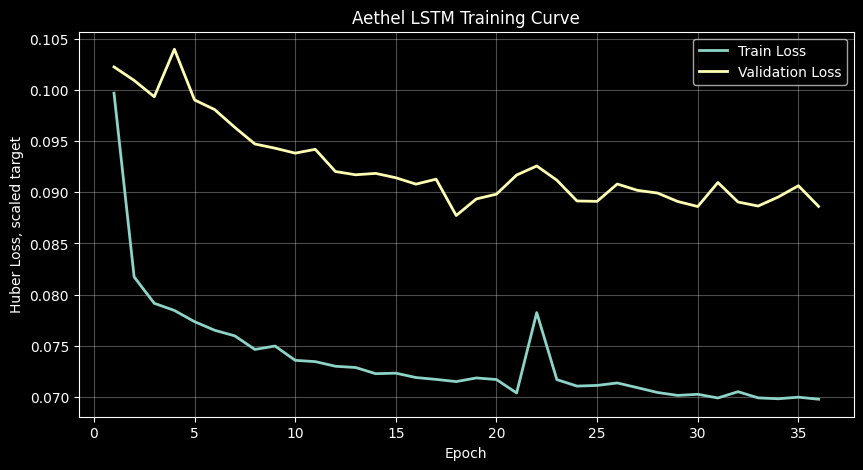

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_frame["epoch"], history_frame["train_loss"], label="Train Loss", linewidth=2)
ax.plot(history_frame["epoch"], history_frame["validation_loss"], label="Validation Loss", linewidth=2)
ax.set_title("Aethel LSTM Training Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss, scaled target")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 10. Deterministic Prediction and Metric Helpers

The model predicts scaled `el_power`, then the target scaler converts predictions back to native power units. All reported metrics below are calculated in original `el_power` units.


In [27]:
@torch.no_grad()
def predict_scaled(model: nn.Module, loader: DataLoader, device: torch.device) -> np.ndarray:
    """Predict scaled target values with dropout disabled."""
    model.eval()
    predictions = []

    for x_batch, _ in loader:
        x_batch = x_batch.to(device, non_blocking=True)
        prediction = model(x_batch).detach().cpu().numpy()
        predictions.append(prediction)

    return np.concatenate(predictions, axis=0)


def inverse_target_vector(values_scaled: np.ndarray) -> np.ndarray:
    """Invert scaling for a one-dimensional target array."""
    values_scaled = np.asarray(values_scaled, dtype=np.float32).reshape(-1, 1)
    return target_scaler.inverse_transform(values_scaled).reshape(-1)


def inverse_target_matrix(values_scaled: np.ndarray) -> np.ndarray:
    """Invert scaling for a 2D MC sample matrix of shape (draws, samples)."""
    values_scaled = np.asarray(values_scaled, dtype=np.float32)
    original_shape = values_scaled.shape
    values_flat = values_scaled.reshape(-1, 1)
    values_unscaled = target_scaler.inverse_transform(values_flat)
    return values_unscaled.reshape(original_shape)


def root_mean_squared_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute RMSE without relying on sklearn version-specific flags."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return core regression metrics in original target units."""
    return {
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


## 11. Global and Regime-Specific Evaluation

The global metrics show overall accuracy. The regime metrics isolate whether the LSTM is doing the important physical work: handling transient power response after voltage steps.


In [28]:
validation_pred_scaled = predict_scaled(model, validation_loader, DEVICE)
validation_pred = inverse_target_vector(validation_pred_scaled)
validation_true = inverse_target_vector(validation_bundle.y)

results = validation_bundle.metadata.copy()
results["y_true"] = validation_true
results["y_pred"] = validation_pred
results["residual"] = results["y_true"] - results["y_pred"]

metrics_global = regression_metrics(results["y_true"].to_numpy(), results["y_pred"].to_numpy())
print("Global validation metrics")
for metric_name, metric_value in metrics_global.items():
    print(f"  {metric_name.upper():<5}: {metric_value:,.4f}")

print("\nRegime RMSE")
regime_rows = []
for phase_name in ["Transition", "Stationary"]:
    phase_frame = results.loc[results["phase"] == phase_name]
    if phase_frame.empty:
        print(f"  {phase_name:<10}: no samples")
        continue

    phase_rmse = root_mean_squared_error(
        phase_frame["y_true"].to_numpy(),
        phase_frame["y_pred"].to_numpy(),
    )
    regime_rows.append(
        {
            "phase": phase_name,
            "samples": len(phase_frame),
            "rmse": phase_rmse,
            "mae": float(mean_absolute_error(phase_frame["y_true"], phase_frame["y_pred"])),
            "r2": float(r2_score(phase_frame["y_true"], phase_frame["y_pred"])),
        }
    )
    print(f"  {phase_name:<10}: RMSE={phase_rmse:,.4f} over {len(phase_frame):,} samples")

regime_metrics = pd.DataFrame(regime_rows)
try:
    display(regime_metrics)
except NameError:
    print(regime_metrics)


Global validation metrics
  RMSE : 337.3671
  MAE  : 184.4786
  R2   : 0.8260

Regime RMSE
  Transition: RMSE=202.2936 over 4,464 samples
  Stationary: RMSE=370.7554 over 13,763 samples


,phase,samples,rmse,mae,r2
0,Transition,4464,202.293621,148.518982,0.920021
1,Stationary,13763,370.755382,196.142090,0.791675


## 12. Monte Carlo Dropout for Uncertainty Estimation

Monte Carlo Dropout keeps dropout active during inference and runs the same validation set multiple times. The spread of these stochastic predictions becomes an approximate uncertainty band.

The 2.5th and 97.5th percentiles form the plotted 95% interval. This is an uncertainty estimate from model stochasticity; production calibration can be improved later with conformal intervals or residual calibration if you collect more held-out runs.


In [29]:
@torch.no_grad()
def predict_with_mc_dropout(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    n_samples: int,
) -> np.ndarray:
    """Run stochastic forward passes with dropout enabled."""
    model.train()
    sample_predictions = []

    for _ in range(n_samples):
        predictions = []
        for x_batch, _ in loader:
            x_batch = x_batch.to(device, non_blocking=True)
            prediction = model(x_batch).detach().cpu().numpy()
            predictions.append(prediction)
        sample_predictions.append(np.concatenate(predictions, axis=0))

    model.eval()
    return np.stack(sample_predictions, axis=0)


mc_predictions_scaled = predict_with_mc_dropout(
    model=model,
    loader=validation_loader,
    device=DEVICE,
    n_samples=MC_DROPOUT_SAMPLES,
)
mc_predictions = inverse_target_matrix(mc_predictions_scaled)

results["y_pred_mc_mean"] = mc_predictions.mean(axis=0)
results["y_pred_lower_95"] = np.percentile(mc_predictions, 2.5, axis=0)
results["y_pred_upper_95"] = np.percentile(mc_predictions, 97.5, axis=0)
results["y_pred_mc_std"] = mc_predictions.std(axis=0)

coverage = np.mean(
    (results["y_true"].to_numpy() >= results["y_pred_lower_95"].to_numpy())
    & (results["y_true"].to_numpy() <= results["y_pred_upper_95"].to_numpy())
)
print(f"MC Dropout validation interval coverage: {coverage:.2%}")


MC Dropout validation interval coverage: 49.33%


## 13. Physics-Aware Visualization on `ex_22`

The plot below shows a 500-step segment from `ex_22`, centered near the first detected transition when possible:

- Orange: `input_voltage`, right axis
- White: ground-truth `el_power`, left axis
- Cyan: LSTM prediction, left axis
- Cyan shaded band: 95% Monte Carlo Dropout interval


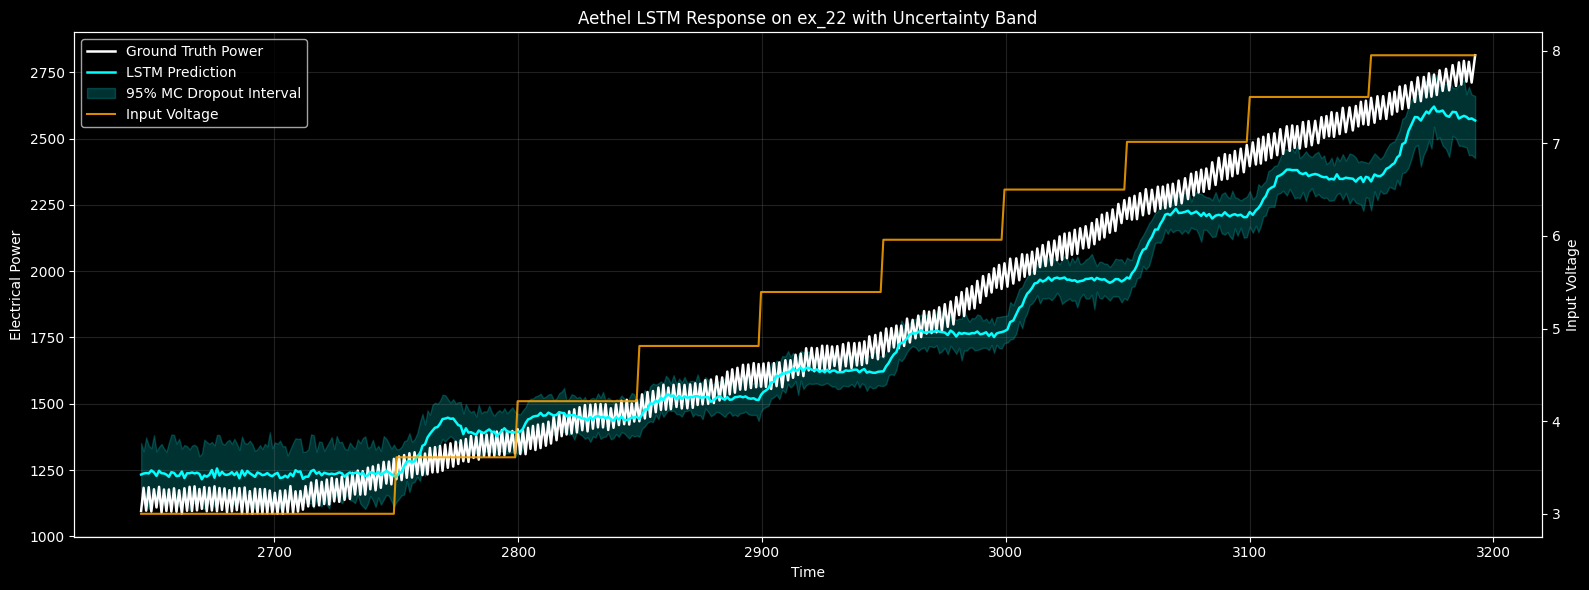

In [30]:
def select_visualization_segment(
    results_frame: pd.DataFrame,
    experiment_id: str,
    segment_length: int,
    pre_transition_context: int = 100,
) -> pd.DataFrame:
    """Select a fixed-length segment, preferably around a transition."""
    experiment_frame = (
        results_frame.loc[results_frame["experiment_id"] == experiment_id]
        .sort_values("target_row")
        .reset_index(drop=True)
    )
    if experiment_frame.empty:
        raise ValueError(f"No results found for {experiment_id}")

    transition_positions = np.flatnonzero(experiment_frame["phase"].eq("Transition").to_numpy())
    if len(transition_positions):
        start = max(int(transition_positions[0]) - pre_transition_context, 0)
    else:
        start = 0

    stop = min(start + segment_length, len(experiment_frame))
    start = max(0, stop - segment_length)
    return experiment_frame.iloc[start:stop].copy()


segment = select_visualization_segment(
    results_frame=results,
    experiment_id="ex_22",
    segment_length=500,
)

plt.style.use("dark_background")
fig, ax_power = plt.subplots(figsize=(16, 6))

ax_power.plot(
    segment["time"],
    segment["y_true"],
    color="white",
    linewidth=1.8,
    label="Ground Truth Power",
)
ax_power.plot(
    segment["time"],
    segment["y_pred_mc_mean"],
    color="cyan",
    linewidth=1.8,
    label="LSTM Prediction",
)
ax_power.fill_between(
    segment["time"].to_numpy(),
    segment["y_pred_lower_95"].to_numpy(),
    segment["y_pred_upper_95"].to_numpy(),
    color="cyan",
    alpha=0.20,
    label="95% MC Dropout Interval",
)
ax_power.set_xlabel("Time")
ax_power.set_ylabel("Electrical Power")
ax_power.grid(True, color="gray", alpha=0.25)

ax_voltage = ax_power.twinx()
ax_voltage.plot(
    segment["time"],
    segment["input_voltage"],
    color="orange",
    linewidth=1.5,
    alpha=0.85,
    label="Input Voltage",
)
ax_voltage.set_ylabel("Input Voltage")

power_handles, power_labels = ax_power.get_legend_handles_labels()
voltage_handles, voltage_labels = ax_voltage.get_legend_handles_labels()
ax_power.legend(
    power_handles + voltage_handles,
    power_labels + voltage_labels,
    loc="upper left",
    frameon=True,
)
ax_power.set_title("Aethel LSTM Response on ex_22 with Uncertainty Band")
fig.tight_layout()
plt.show()


## 14. Export Model and Deployment Metadata

The export contains:

- `aethel_lstm_el_power.pth`: model state, architecture hyperparameters, metrics, and feature schema
- `feature_scaler.joblib`: fitted scaler for live voltage windows
- `target_scaler.joblib`: fitted scaler used to invert model outputs
- `deployment_config.json`: lightweight config for a FastAPI service
- `validation_predictions.csv`: deterministic and MC Dropout predictions for validation analysis


In [31]:
results.to_csv(PREDICTIONS_PATH, index=False)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_class": "AethelLSTM",
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "time_column": TIME_COLUMN,
    "lookback_steps": LOOKBACK_STEPS,
    "lookback_seconds": LOOKBACK_SECONDS,
    "median_dt_seconds": MEDIAN_DT_SECONDS,
    "hidden_size": HIDDEN_SIZE,
    "num_lstm_layers": NUM_LSTM_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "scaler_kind": SCALER_KIND,
    "voltage_step_threshold": VOLTAGE_STEP_THRESHOLD,
    "transition_window_steps": TRANSITION_WINDOW_STEPS,
    "train_experiments": TRAIN_EXPERIMENTS,
    "validation_experiments": VALIDATION_EXPERIMENTS,
    "global_validation_metrics": metrics_global,
    "regime_validation_metrics": regime_metrics.to_dict(orient="records"),
    "random_seed": RANDOM_SEED,
}

torch.save(checkpoint, MODEL_PATH)
joblib.dump(feature_scaler, FEATURE_SCALER_PATH)
joblib.dump(target_scaler, TARGET_SCALER_PATH)

with CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump(
        {
            key: value
            for key, value in checkpoint.items()
            if key != "model_state_dict"
        },
        file,
        indent=2,
    )


## 15. FastAPI Inference Helper Pattern

This cell mirrors what your backend can do at startup and request time. A live request should provide the most recent `LOOKBACK_STEPS` values for every feature in `FEATURE_COLUMNS`. With the default configuration, that means the last 30-ish `input_voltage` readings.


In [32]:
def load_deployed_model(
    model_path: Path,
    feature_scaler_path: Path,
    target_scaler_path: Path,
    device: torch.device = torch.device("cpu"),
):
    """Load checkpoint, scalers, and ready-to-run model for an API service."""
    loaded_checkpoint = torch.load(model_path, map_location=device)
    loaded_model = AethelLSTM(
        n_features=len(loaded_checkpoint["feature_columns"]),
        hidden_size=loaded_checkpoint["hidden_size"],
        num_layers=loaded_checkpoint["num_lstm_layers"],
        dropout=loaded_checkpoint["dropout_rate"],
    ).to(device)
    loaded_model.load_state_dict(loaded_checkpoint["model_state_dict"])
    loaded_model.eval()

    loaded_feature_scaler = joblib.load(feature_scaler_path)
    loaded_target_scaler = joblib.load(target_scaler_path)
    return loaded_model, loaded_checkpoint, loaded_feature_scaler, loaded_target_scaler


@torch.no_grad()
def predict_power_from_voltage_window(
    voltage_window: Iterable[float],
    loaded_model: nn.Module,
    loaded_checkpoint: dict,
    loaded_feature_scaler,
    loaded_target_scaler,
    device: torch.device = torch.device("cpu"),
) -> float:
    """Predict current electrical power from a recent voltage history."""
    voltage_values = np.asarray(list(voltage_window), dtype=np.float32)
    lookback_steps = int(loaded_checkpoint["lookback_steps"])

    if len(voltage_values) != lookback_steps:
        raise ValueError(f"Expected {lookback_steps} voltage readings, received {len(voltage_values)}")

    feature_frame = pd.DataFrame({"input_voltage": voltage_values})
    features_scaled = loaded_feature_scaler.transform(
        feature_frame[loaded_checkpoint["feature_columns"]].to_numpy(dtype=np.float32)
    )
    x_tensor = torch.as_tensor(features_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    prediction_scaled = loaded_model(x_tensor).detach().cpu().numpy().reshape(-1, 1)
    prediction = loaded_target_scaler.inverse_transform(prediction_scaled).reshape(-1)[0]
    return float(prediction)


# Smoke-test the deployment helper with the last validation sequence.
deployed_model, deployed_checkpoint, deployed_feature_scaler, deployed_target_scaler = load_deployed_model(
    MODEL_PATH,
    FEATURE_SCALER_PATH,
    TARGET_SCALER_PATH,
    device=DEVICE,
)
example_voltage_window_scaled = validation_bundle.x[-1, :, 0].reshape(-1, 1)
example_voltage_window = feature_scaler.inverse_transform(example_voltage_window_scaled).reshape(-1)
example_prediction = predict_power_from_voltage_window(
    voltage_window=example_voltage_window,
    loaded_model=deployed_model,
    loaded_checkpoint=deployed_checkpoint,
    loaded_feature_scaler=deployed_feature_scaler,
    loaded_target_scaler=deployed_target_scaler,
    device=DEVICE,
)
print(f"Example deployed prediction: {example_prediction:,.4f}")


Example deployed prediction: 1,239.6814
